  Stevan Maciel Ribeiro de Souza - 2022003307

#Instalação e Importação de Bibliotecas

In [ ]:
# Instalar bibliotecas
!pip install --quiet nltk

# Importações gerais
import pandas as pd
import numpy as np
import time
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import HashingVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Classificadores
from sklearn.linear_model import LogisticRegression, SGDClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, ComplementNB
from sklearn.neighbors import NearestCentroid, KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# NLTK para stopwords em português
import nltk
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


#Carregamento e Exploração Inicial dos Dados

In [ ]:
from google.colab import files
files.upload()

import os
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

!kaggle datasets download -d leandrodoze/tweets-from-mgbr

import zipfile
with zipfile.ZipFile("tweets-from-mgbr.zip", "r") as zip_ref:
    zip_ref.extractall("tweets-from-mgbr_Data")

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/leandrodoze/tweets-from-mgbr
License(s): ODbL-1.0
  0% 0.00/392k [00:00<?, ?B/s]
100% 392k/392k [00:00<00:00, 701MB/s]


In [ ]:
# Carregar o dataset
try:
    df = pd.read_csv('tweets-from-mgbr_Data/Tweets_Mg.csv', encoding='utf-8')
except FileNotFoundError:
    print("Erro: Arquivo 'Tweets_MG.csv' não encontrado. "
          "Por favor, faça o upload do arquivo para o Colab.")
    exit()
except Exception as e:
    print(f"Tentando carregar com encoding latin1 devido a erro: {e}")
    try:
        df = pd.read_csv('Tweets_MG.csv', encoding='latin1')
    except Exception as e_latin1:
        print(f"Erro ao carregar com latin1 também: {e_latin1}")
        exit()

print("Informações do Dataset:")
df.info()

print("\nPrimeiras 5 linhas:")
print(df.head())

print("\nDistribuição da variável alvo 'Classificacao':")
print(df['Classificacao'].value_counts(dropna=False))

# Verificar se há dados nulos nas colunas relevantes
print("\nValores nulos em 'Text' e 'Classificacao':")
print(df[['Text', 'Classificacao']].isnull().sum())

# Remover linhas onde 'Text' ou 'Classificacao' são nulos, se houver
df.dropna(subset=['Text', 'Classificacao'], inplace=True)

print("\nDistribuição da variável alvo 'Classificacao' após remover nulos (se houver):")
print(df['Classificacao'].value_counts())

# Selecionar as colunas de interesse
X = df['Text']
y = df['Classificacao']

print(f"\nNúmero de amostras: {len(X)}")

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8199 entries, 0 to 8198
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Unnamed: 0                 8199 non-null   int64  
 1   Created At                 8199 non-null   object 
 2   Text                       8199 non-null   object 
 3   Geo Coordinates.latitude   104 non-null    float64
 4   Geo Coordinates.longitude  104 non-null    float64
 5   User Location              5489 non-null   object 
 6   Username                   8199 non-null   object 
 7   User Screen Name           8199 non-null   object 
 8   Retweet Count              8199 non-null   int64  
 9   Classificacao              8199 non-null   object 
 10  Observação                 1 non-null      object 
 11  Unnamed: 10                0 non-null      float64
 12  Unnamed: 11                0 non-null      float64
 13  Unnamed: 12             

#Divisão dos Dados

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do conjunto de treino: {len(X_train)}")
print(f"Tamanho do conjunto de teste: {len(X_test)}")
print(f"Distribuição das classes no treino:\n{y_train.value_counts(normalize=True)}")
print(f"Distribuição das classes no teste:\n{y_test.value_counts(normalize=True)}")

target_names = sorted(y.unique())
print(f"\nClasses do alvo: {target_names}")

Tamanho do conjunto de treino: 6559
Tamanho do conjunto de teste: 1640
Distribuição das classes no treino:
Classificacao
Positivo    0.402500
Neutro      0.299131
Negativo    0.298369
Name: proportion, dtype: float64
Distribuição das classes no teste:
Classificacao
Positivo    0.402439
Neutro      0.299390
Negativo    0.298171
Name: proportion, dtype: float64

Classes do alvo: ['Negativo', 'Neutro', 'Positivo']


#Definição da Função de Benchmark e Parâmetros

In [ ]:
# Obter stopwords em português
stop_words_pt = stopwords.words('portuguese')

# Parâmetros para HashingVectorizer e SelectKBest
# N_FEATURES_OPTIONS = [2**16, 2**18, 2**20] # Diferentes números de features para HashingVectorizer
N_FEATURES_OPTIONS = [2**18] # Um valor razoável para começar
K_BEST_OPTIONS = [10000, 20000] # Número de features a serem selecionadas pelo SelectKBest
# K_BEST_OPTIONS = ['all'] # Para não usar SelectKBest ou um número específico

results = []

def benchmark(clf_name, clf, X_train_data, y_train_data, X_test_data, y_test_data,
              target_names_list, use_feature_selection=True, k_val='all'):
    """
    Função para construir o pipeline, treinar, avaliar e registrar os resultados.
    """
    print(f"\n--- Avaliando: {clf_name} ---")
    if use_feature_selection and k_val != 'all':
        print(f"Seleção de Features: SelectKBest com k={k_val}")
        pipeline_components = [
            ('vectorizer', HashingVectorizer(stop_words=stop_words_pt, alternate_sign=False,
                                             n_features=N_FEATURES_OPTIONS[0], norm=None,
                                             ngram_range=(1,2))),
            ('tfidf', TfidfTransformer()),
            ('selector', SelectKBest(chi2, k=k_val)),
            ('classifier', clf),
        ]
    else:
        print("Seleção de Features: Desativada (usando todas as features do Tfidf)")
        pipeline_components = [
            ('vectorizer', HashingVectorizer(stop_words=stop_words_pt, alternate_sign=False,
                                             n_features=N_FEATURES_OPTIONS[0], norm=None,
                                             ngram_range=(1,2))),
            ('tfidf', TfidfTransformer()),
            ('classifier', clf),
        ]

    pipeline = Pipeline(pipeline_components)

    # Treinamento
    print("Treinando o modelo...")
    t0 = time.time()
    pipeline.fit(X_train_data, y_train_data)
    train_time = time.time() - t0
    print(f"Tempo de treino: {train_time:.3f}s")

    # Teste
    print("Prevendo no conjunto de teste...")
    t0 = time.time()
    y_pred = pipeline.predict(X_test_data)
    test_time = time.time() - t0
    print(f"Tempo de teste: {test_time:.3f}s")

    # Avaliação
    accuracy = accuracy_score(y_test_data, y_pred)
    print(f"Acurácia: {accuracy:.4f}")

    print("\nRelatório de Classificação:")
    report = classification_report(y_test_data, y_pred, target_names=target_names_list, output_dict=True)
    print(classification_report(y_test_data, y_pred, target_names=target_names_list))

    # Armazenar resultados
    results.append({
        'Classifier': clf_name,
        'Accuracy': accuracy,
        'Train Time (s)': train_time,
        'Test Time (s)': test_time,
        'k_features': k_val if use_feature_selection else 'all',
        'Precision (macro)': report['macro avg']['precision'],
        'Recall (macro)': report['macro avg']['recall'],
        'F1-score (macro)': report['macro avg']['f1-score']
    })

    # Matriz de Confusão
    cm = confusion_matrix(y_test_data, y_pred, labels=target_names_list)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names_list, yticklabels=target_names_list)
    plt.title(f'Matriz de Confusão - {clf_name}')
    plt.ylabel('Verdadeiro')
    plt.xlabel('Previsto')
    plt.show()

    return accuracy, train_time, test_time

#Definição e Treinamento dos Classificadores

=== Iniciando benchmark com k=10000 para SelectKBest ===

--- Avaliando: Logistic Regression ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 3.117s
Prevendo no conjunto de teste...
Tempo de teste: 0.149s
Acurácia: 0.9659

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.97      0.95      0.96       489
      Neutro       0.92      0.97      0.94       491
    Positivo       1.00      0.97      0.99       660

    accuracy                           0.97      1640
   macro avg       0.96      0.96      0.96      1640
weighted avg       0.97      0.97      0.97      1640



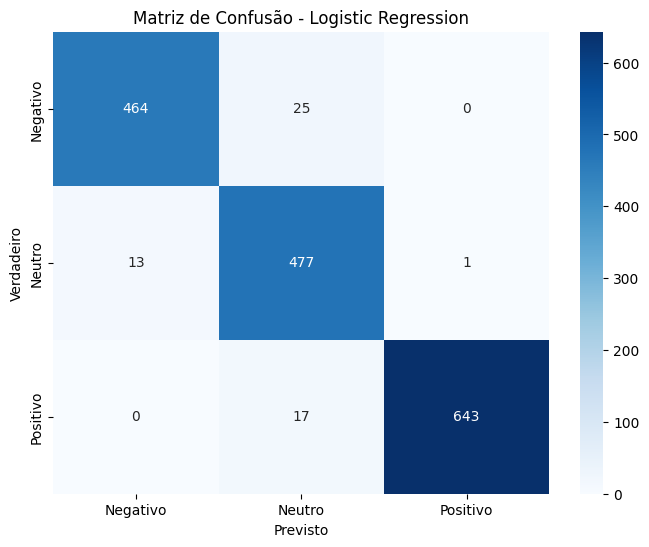


--- Avaliando: Linear SVC ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 6.186s
Prevendo no conjunto de teste...
Tempo de teste: 0.113s
Acurácia: 0.9646

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.97      0.95      0.96       489
      Neutro       0.92      0.97      0.94       491
    Positivo       1.00      0.97      0.99       660

    accuracy                           0.96      1640
   macro avg       0.96      0.96      0.96      1640
weighted avg       0.97      0.96      0.96      1640



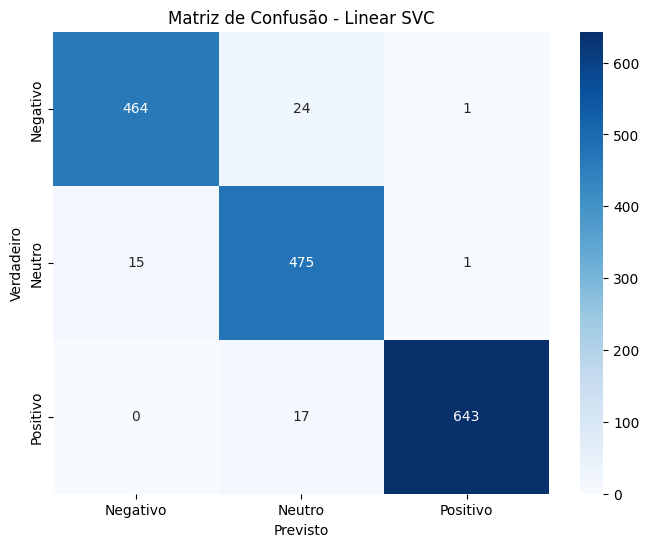


--- Avaliando: SGD Classifier (Hinge) ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 2.918s
Prevendo no conjunto de teste...
Tempo de teste: 0.250s
Acurácia: 0.9622

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.97      0.95      0.96       489
      Neutro       0.91      0.97      0.94       491
    Positivo       1.00      0.97      0.98       660

    accuracy                           0.96      1640
   macro avg       0.96      0.96      0.96      1640
weighted avg       0.96      0.96      0.96      1640



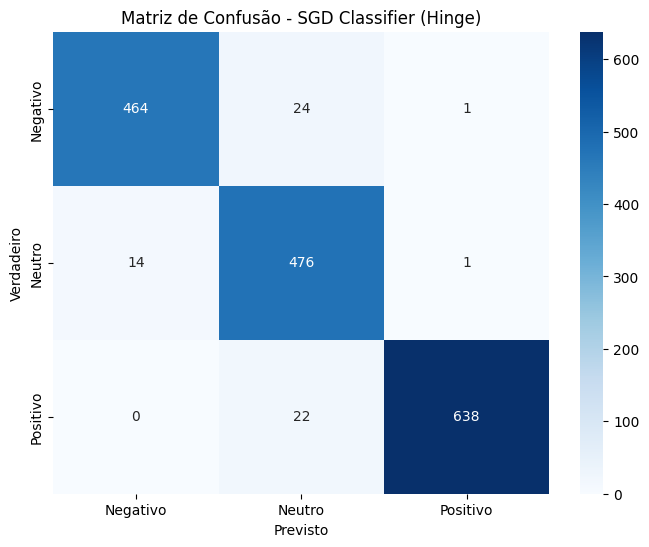


--- Avaliando: SGD Classifier (Log) ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 4.170s
Prevendo no conjunto de teste...
Tempo de teste: 0.178s
Acurácia: 0.9585

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.97      0.94      0.96       489
      Neutro       0.90      0.97      0.93       491
    Positivo       0.99      0.97      0.98       660

    accuracy                           0.96      1640
   macro avg       0.96      0.96      0.96      1640
weighted avg       0.96      0.96      0.96      1640



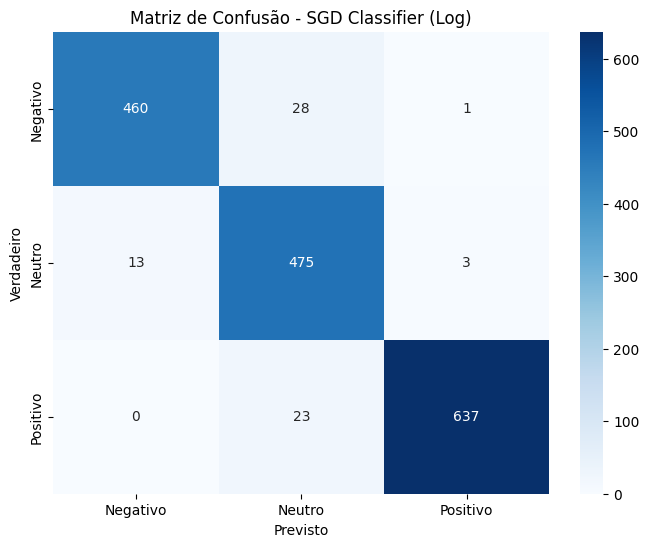


--- Avaliando: SGD Classifier (Perceptron) ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 3.784s
Prevendo no conjunto de teste...
Tempo de teste: 0.048s
Acurácia: 0.9646

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.97      0.96      0.96       489
      Neutro       0.93      0.96      0.94       491
    Positivo       0.99      0.97      0.98       660

    accuracy                           0.96      1640
   macro avg       0.96      0.96      0.96      1640
weighted avg       0.97      0.96      0.96      1640



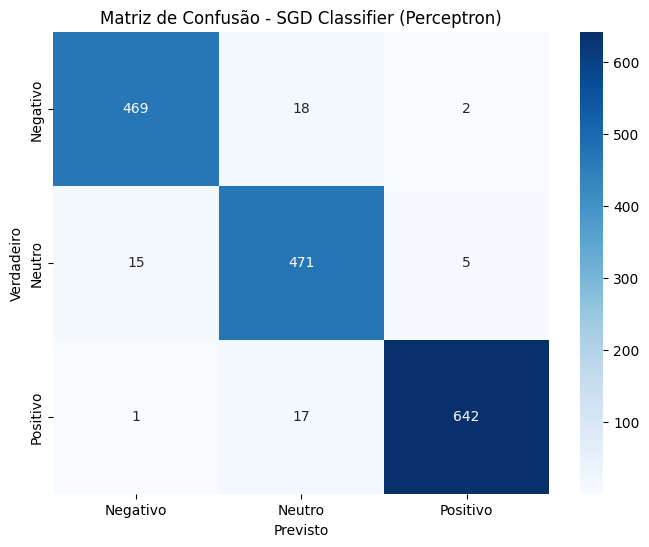


--- Avaliando: Multinomial Naive Bayes ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 1.477s
Prevendo no conjunto de teste...
Tempo de teste: 0.044s
Acurácia: 0.9512

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.95      0.95      0.95       489
      Neutro       0.92      0.92      0.92       491
    Positivo       0.97      0.97      0.97       660

    accuracy                           0.95      1640
   macro avg       0.95      0.95      0.95      1640
weighted avg       0.95      0.95      0.95      1640



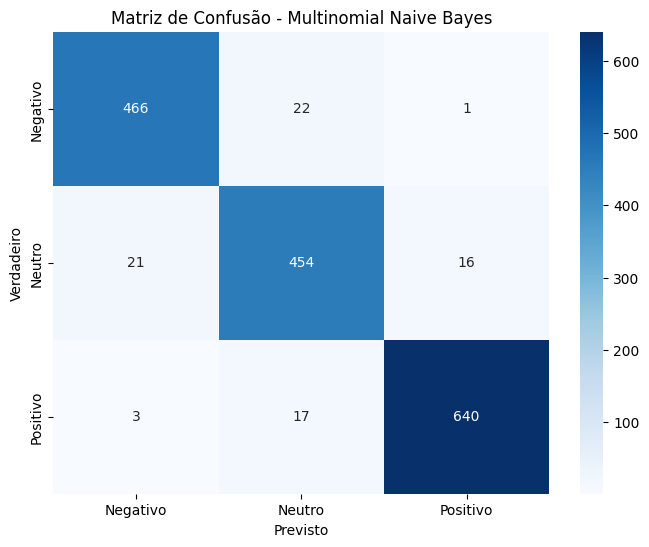


--- Avaliando: Bernoulli Naive Bayes ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 1.468s
Prevendo no conjunto de teste...
Tempo de teste: 0.046s
Acurácia: 0.9585

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.97      0.96      0.96       489
      Neutro       0.92      0.95      0.93       491
    Positivo       0.98      0.97      0.98       660

    accuracy                           0.96      1640
   macro avg       0.96      0.96      0.96      1640
weighted avg       0.96      0.96      0.96      1640



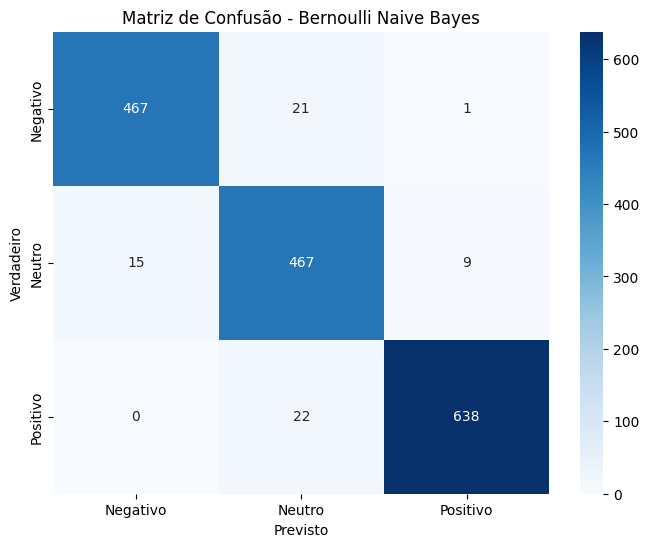


--- Avaliando: Complement Naive Bayes ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 1.492s
Prevendo no conjunto de teste...
Tempo de teste: 0.044s
Acurácia: 0.9537

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.94      0.96      0.95       489
      Neutro       0.93      0.93      0.93       491
    Positivo       0.98      0.97      0.98       660

    accuracy                           0.95      1640
   macro avg       0.95      0.95      0.95      1640
weighted avg       0.95      0.95      0.95      1640



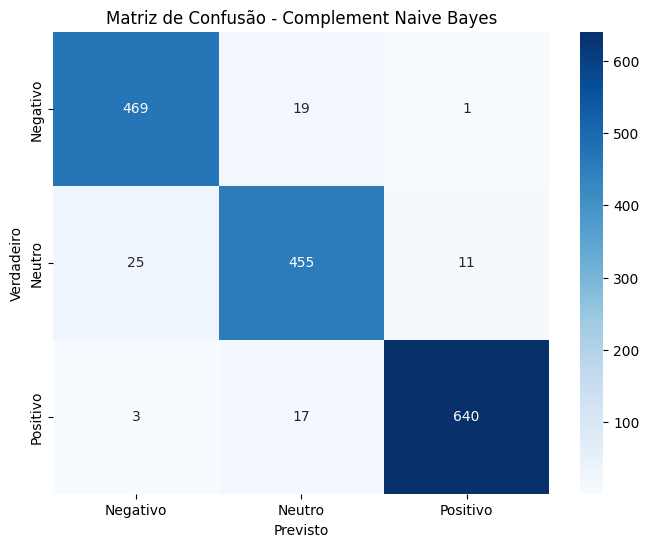


--- Avaliando: Passive-Aggressive ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 1.673s
Prevendo no conjunto de teste...
Tempo de teste: 0.048s
Acurácia: 0.9640

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.96      0.96      0.96       489
      Neutro       0.94      0.95      0.94       491
    Positivo       0.99      0.98      0.98       660

    accuracy                           0.96      1640
   macro avg       0.96      0.96      0.96      1640
weighted avg       0.96      0.96      0.96      1640



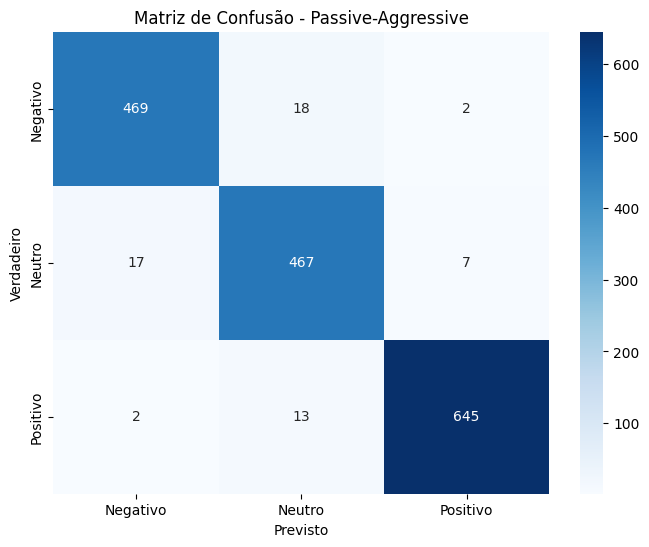


--- Avaliando: Perceptron ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 1.747s
Prevendo no conjunto de teste...
Tempo de teste: 0.079s
Acurácia: 0.9530

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.97      0.95      0.96       489
      Neutro       0.91      0.94      0.93       491
    Positivo       0.98      0.96      0.97       660

    accuracy                           0.95      1640
   macro avg       0.95      0.95      0.95      1640
weighted avg       0.95      0.95      0.95      1640



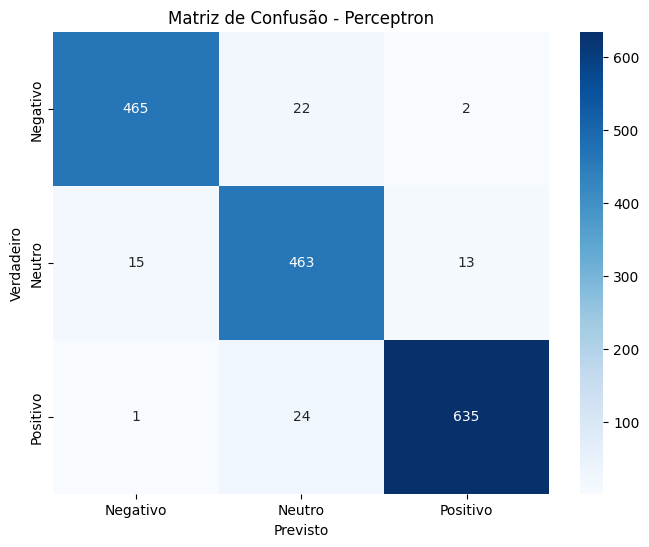


--- Avaliando: Nearest Centroid (Rocchio) ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 2.809s
Prevendo no conjunto de teste...
Tempo de teste: 0.094s
Acurácia: 0.8530

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.99      0.66      0.79       489
      Neutro       0.67      0.99      0.80       491
    Positivo       0.99      0.90      0.94       660

    accuracy                           0.85      1640
   macro avg       0.89      0.85      0.85      1640
weighted avg       0.90      0.85      0.86      1640



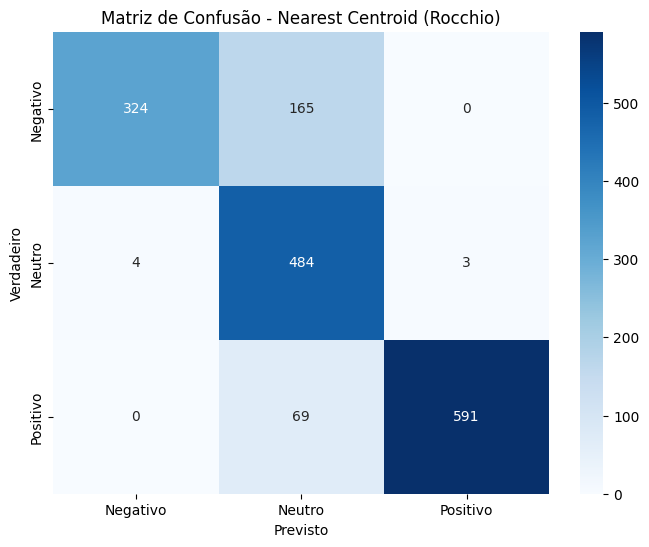


--- Avaliando: Random Forest (100 trees) ---
Seleção de Features: SelectKBest com k=10000
Treinando o modelo...
Tempo de treino: 3.584s
Prevendo no conjunto de teste...
Tempo de teste: 0.088s
Acurácia: 0.9646

Relatório de Classificação:
              precision    recall  f1-score   support

    Negativo       0.97      0.96      0.96       489
      Neutro       0.92      0.97      0.94       491
    Positivo       0.99      0.97      0.98       660

    accuracy                           0.96      1640
   macro avg       0.96      0.96      0.96      1640
weighted avg       0.97      0.96      0.96      1640



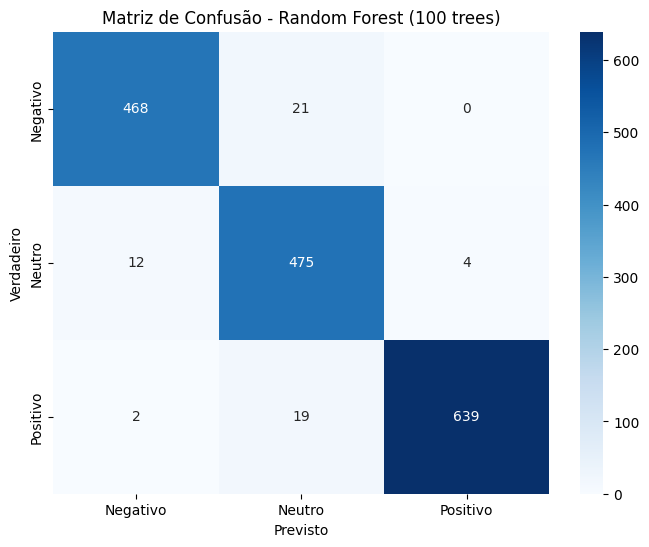

In [ ]:
# Lista de classificadores para testar
# (Nome, Instância do Classificador)

classifiers_to_test = [
    ("Logistic Regression", LogisticRegression(solver='liblinear', random_state=42, C=10)), # C=10 como no exemplo sk
    ("Linear SVC", LinearSVC(C=1, dual=False, max_iter=3000)), # dual=False for n_samples > n_features
    ("SGD Classifier (Hinge)", SGDClassifier(loss='hinge', penalty='l2', alpha=1e-4, random_state=42, max_iter=100, tol=None)),
    ("SGD Classifier (Log)", SGDClassifier(loss='log_loss', penalty='l2', alpha=1e-4, random_state=42, max_iter=100, tol=None)), # Para regressão logística
    ("SGD Classifier (Perceptron)", SGDClassifier(loss='perceptron', penalty='l2', alpha=1e-4, random_state=42, max_iter=100, tol=None)),
    ("Multinomial Naive Bayes", MultinomialNB(alpha=0.01)),
    ("Bernoulli Naive Bayes", BernoulliNB(alpha=0.01)),
    ("Complement Naive Bayes", ComplementNB(alpha=0.1)), # alpha diferente, bom para datasets desbalanceados
    ("Passive-Aggressive", PassiveAggressiveClassifier(C=0.1, max_iter=100, random_state=42, tol=None)),
    ("Perceptron", Perceptron(penalty='l2', alpha=1e-4, max_iter=100, random_state=42, tol=None)),
    ("Nearest Centroid (Rocchio)", NearestCentroid()),
    ("Random Forest (100 trees)", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
]

# Testar com e sem seleção de features (e com diferentes k)
# Para uma comparação mais direta, vamos fixar um k para SelectKBest ou não usar.
# Vamos usar k=10000 como um exemplo.
k_to_use = 10000 # Ou 'all' para não usar SelectKBest, ou outro valor de K_BEST_OPTIONS

print(f"=== Iniciando benchmark com k={k_to_use} para SelectKBest ===")
for clf_name, clf_instance in classifiers_to_test:
    benchmark(clf_name, clf_instance, X_train, y_train, X_test, y_test,
              target_names, use_feature_selection=True, k_val=k_to_use)

#Comparação dos Resultados



--- Tabela Comparativa dos Resultados ---
|    | Classifier                  |   k_features |   Accuracy |   F1-score (macro) |   Precision (macro) |   Recall (macro) |   Train Time (s) |   Test Time (s) |
|---:|:----------------------------|-------------:|-----------:|-------------------:|--------------------:|-----------------:|-----------------:|----------------:|
|  0 | Logistic Regression         |        10000 |     0.9659 |             0.9638 |              0.9634 |           0.9649 |           3.1171 |          0.1485 |
| 11 | Random Forest (100 trees)   |        10000 |     0.9646 |             0.9630 |              0.9624 |           0.9642 |           3.5838 |          0.0876 |
|  4 | SGD Classifier (Perceptron) |        10000 |     0.9646 |             0.9629 |              0.9624 |           0.9637 |           3.7836 |          0.0478 |
|  1 | Linear SVC                  |        10000 |     0.9646 |             0.9625 |              0.9620 |           0.9635 |          

<ipython-input-7-438558688f1e>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Classifier', data=results_df, palette='viridis')
<ipython-input-7-438558688f1e>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='F1-score (macro)', y='Classifier', data=results_df, palette='mako')


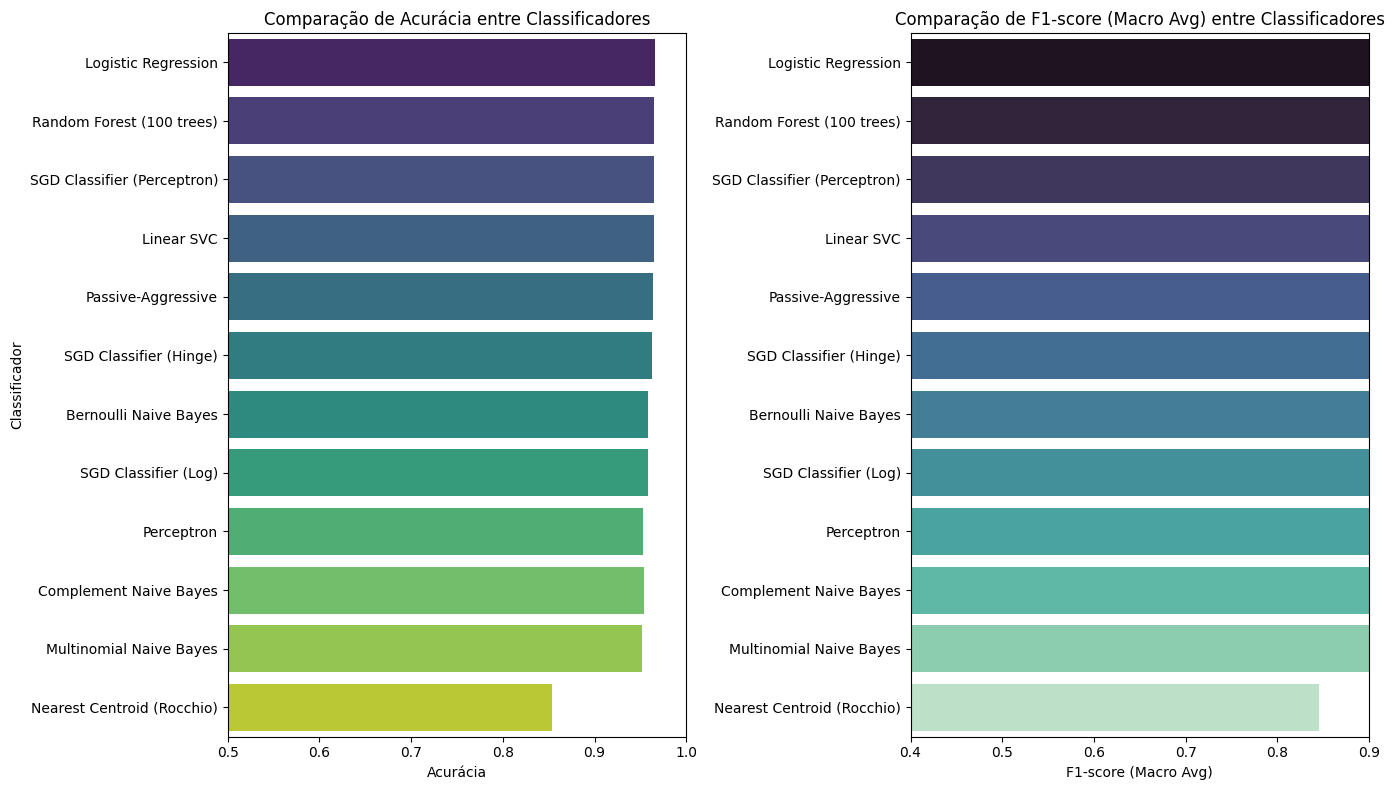



--- Melhores Classificadores ---
                     Classifier  k_features  Accuracy  F1-score (macro)  \
0           Logistic Regression       10000  0.965854          0.963804   
11    Random Forest (100 trees)       10000  0.964634          0.963034   
4   SGD Classifier (Perceptron)       10000  0.964634          0.962925   

    Precision (macro)  Recall (macro)  Train Time (s)  Test Time (s)  
0            0.963423        0.964868        3.117146       0.148539  
11           0.962355        0.964217        3.583764       0.087554  
4            0.962352        0.963698        3.783580       0.047835  


In [ ]:
# Organizar e exibir os resultados em uma tabela
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='F1-score (macro)', ascending=False) # Ordenar pelo F1-score

print("\n\n--- Tabela Comparativa dos Resultados ---")
# Usando tabulate para uma impressão mais limpa no console do Colab
headers = ["Classifier", "k_features", "Accuracy", "F1-score (macro)", "Precision (macro)", "Recall (macro)", "Train Time (s)", "Test Time (s)"]
print(tabulate(results_df[headers], headers="keys", tablefmt="pipe", floatfmt=".4f"))

# Plotar um gráfico comparativo de Acurácia e F1-score
plt.figure(figsize=(14, 8))

# Acurácia
plt.subplot(1, 2, 1)
sns.barplot(x='Accuracy', y='Classifier', data=results_df, palette='viridis')
plt.title('Comparação de Acurácia entre Classificadores')
plt.xlabel('Acurácia')
plt.ylabel('Classificador')
plt.xlim(0.5, 1.0)

# F1-score (macro)
plt.subplot(1, 2, 2)
sns.barplot(x='F1-score (macro)', y='Classifier', data=results_df, palette='mako')
plt.title('Comparação de F1-score (Macro Avg) entre Classificadores')
plt.xlabel('F1-score (Macro Avg)')
plt.ylabel('')
plt.xlim(0.4, 0.9)

plt.tight_layout()
plt.show()

print("\n\n--- Melhores Classificadores ---")
print(results_df.head(3)[headers])